In [58]:
import snntorch as snn
import torch

In [59]:
batch_size = 128
data_path = '/tmp/data/mnist'
num_classes = 10

dtype = torch.float

In [60]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0,), (1,))
])

mnist_train = datasets.MNIST(data_path, train=True, download=True, transform=transform)

In [61]:
from snntorch import utils

subset = 10
mnist_train = utils.data_subset(mnist_train, subset)
print(f"The size of mnist_train is {len(mnist_train)}")

The size of mnist_train is 6000


In [62]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    mnist_train, 
    batch_size=batch_size, 
    shuffle=True
)

In [63]:
num_steps = 100
raw_vector = torch.ones(num_steps)*0.5
rate_coded_vector = torch.bernoulli(raw_vector)

print(f"Converted vector: {rate_coded_vector}")
print(f"The output is spiking {rate_coded_vector.sum()*100/len(rate_coded_vector):.2f}% of the time.")

Converted vector: tensor([1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 1., 0., 1., 0., 0., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 0., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1.,
        1., 1., 1., 0., 0., 0., 0., 0., 0., 1., 1., 0., 1., 1., 0., 0., 1., 0.,
        1., 0., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 0., 0., 0., 1.,
        0., 1., 1., 1., 0., 0., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 1.,
        0., 1., 1., 0., 0., 0., 1., 0., 0., 0.])
The output is spiking 53.00% of the time.


In [64]:
from snntorch import spikegen

data = iter(train_loader)
data_it, targets_it = next(data)

spike_data = spikegen.rate(data_it, num_steps=num_steps)

print(spike_data.size())

torch.Size([100, 128, 1, 28, 28])


In [65]:
import matplotlib.pyplot as plt
import snntorch.spikeplot as splt
from IPython.display import HTML

In [66]:
spike_data_sample = spike_data[:, 0, 0]
print(spike_data_sample.size())

torch.Size([100, 28, 28])


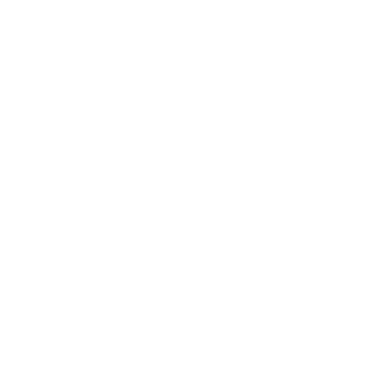

In [67]:
fig, ax = plt.subplots()
anim = splt.animator(spike_data_sample, fig, ax)

HTML(anim.to_html5_video())

In [68]:
print(f"The corresponding target is: {targets_it[0]}")

The corresponding target is: 6


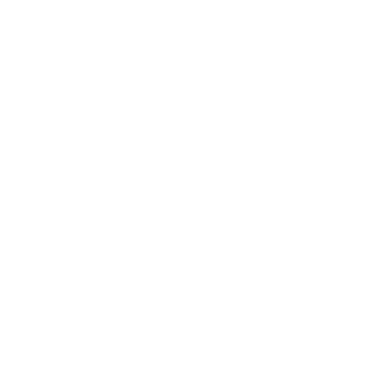

In [69]:
spike_data = spikegen.rate(
    data_it, 
    num_steps=num_steps, 
    gain=0.25,
)

spike_data_sample2 = spike_data[:, 0, 0]
fig, ax = plt.subplots()
anim = splt.animator(spike_data_sample2, fig, ax)
HTML(anim.to_html5_video())

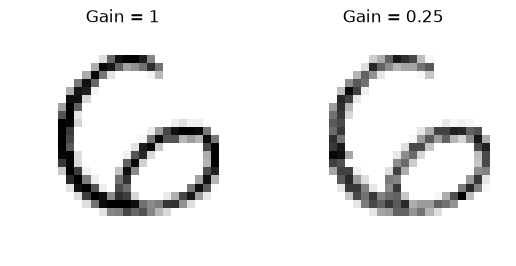

In [70]:
plt.figure(facecolor="w")
plt.subplot(1, 2, 1)
plt.imshow(spike_data_sample.mean(axis=0).reshape((28,-1)).cpu(), cmap='binary')
plt.axis('off')
plt.title('Gain = 1')

plt.subplot(1, 2, 2)
plt.imshow(spike_data_sample2.mean(axis=0).reshape((28,-1)).cpu(), cmap='binary')
plt.axis('off')
plt.title('Gain = 0.25')
plt.show()

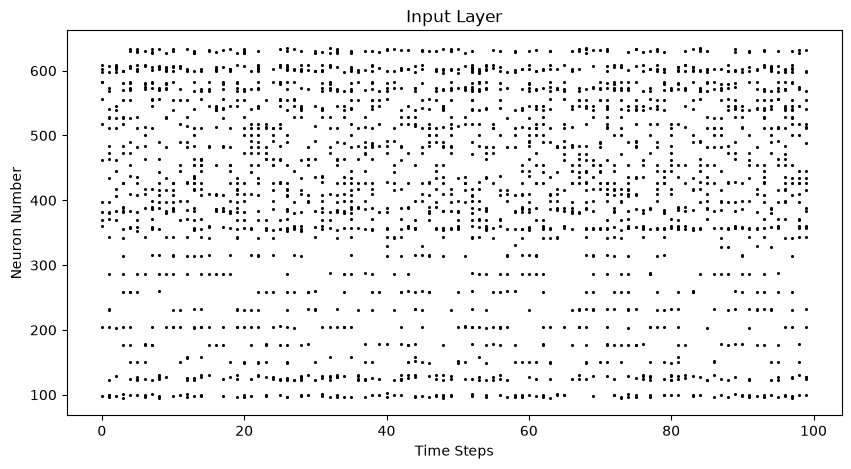

In [80]:
spike_data_sample2 = spike_data_sample2.reshape((num_steps, -1))

fig = plt.figure(facecolor="w", figsize=(10, 5))
ax = fig.add_subplot(111)
splt.raster(spike_data_sample2, ax, s=1.5, c="black")

plt.title("Input Layer")
plt.xlabel("Time Steps")
plt.ylabel("Neuron Number")
plt.show()

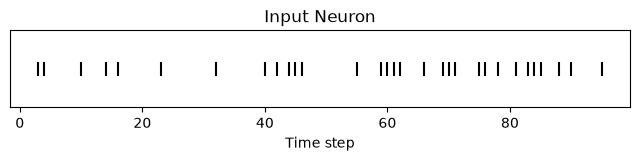

In [88]:
idx = 203

fig = plt.figure(facecolor="w", figsize=(8,1))
ax = fig.add_subplot(111)

splt.raster(
    data=spike_data_sample.reshape(num_steps, -1)[:, idx].unsqueeze(1),
    ax=ax,
    s=100,
    c="black",
    marker="|",
)

plt.title("Input Neuron")
plt.xlabel("Time step")
plt.yticks([])
plt.show()

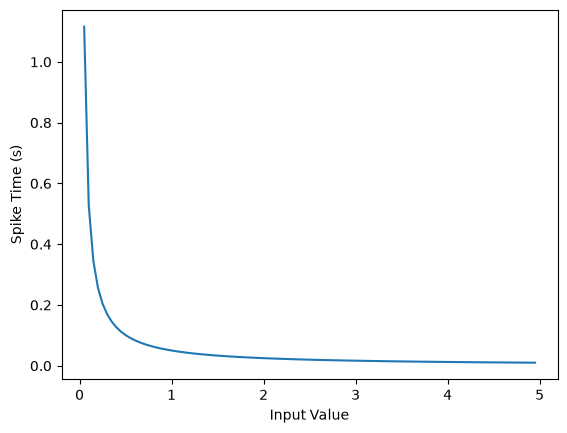

In [93]:
def convert_to_time(data, tau=5, threshold=0.01):
    spike_time = tau * torch.log(data / (data - threshold))
    return spike_time

raw_input = torch.arange(0, 5, 0.05)
spike_times = convert_to_time(raw_input)

plt.plot(raw_input, spike_times)
plt.xlabel("Input Value")
plt.ylabel("Spike Time (s)")
plt.show()

In [105]:
spike_data = spikegen.latency(data_it, num_steps=100, tau=5, threshold=0.01)

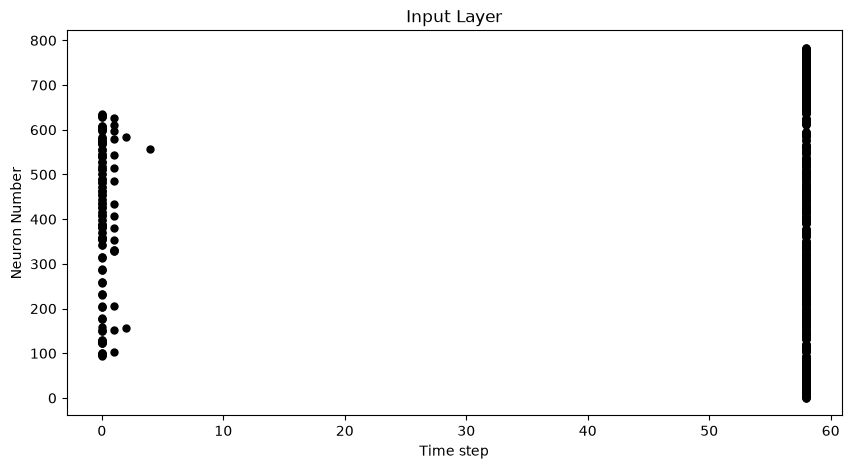

In [106]:
fig = plt.figure(facecolor="w", figsize=(10, 5))
ax = fig.add_subplot(111)
splt.raster(spike_data[:, 0].view(num_steps, -1), ax, s=25, c="black")

plt.title("Input Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()

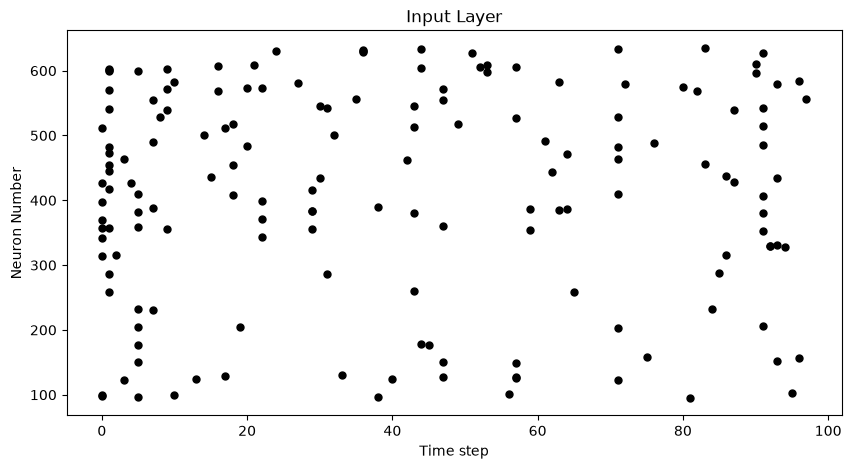

In [107]:
spike_data = spikegen.latency(data_it, num_steps=100, tau=5, threshold=0.01, linear=True, clip=True, normalize=True)

fig = plt.figure(facecolor="w", figsize=(10, 5))
ax = fig.add_subplot(111)
splt.raster(spike_data[:, 0].view(num_steps, -1), ax, s=25, c="black")
plt.title("Input Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()

torch.Size([100, 28, 28])


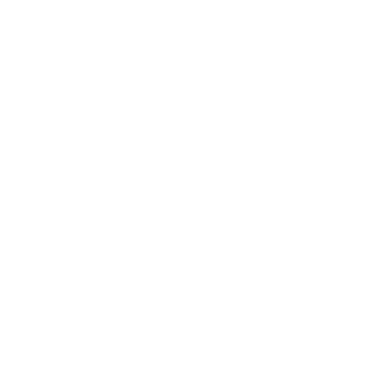

In [109]:
spike_data_sample = spike_data[:, 0, 0]
print(spike_data_sample.size())

fig, ax = plt.subplots()
anim = splt.animator(spike_data_sample, fig, ax)

HTML(anim.to_html5_video())

In [110]:
print(targets_it[0])

tensor(6)


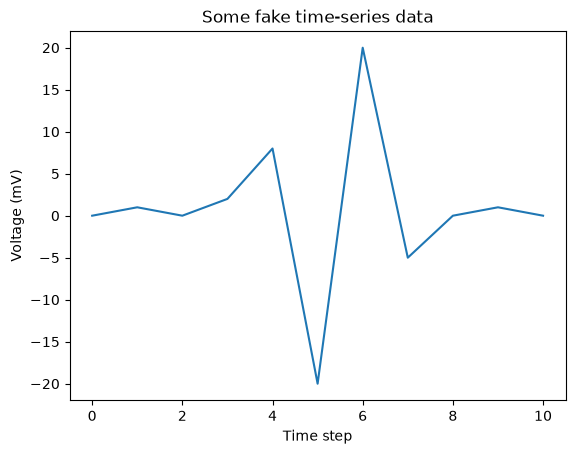

In [113]:
data = torch.Tensor([0, 1, 0, 2, 8, -20, 20, -5, 0, 1, 0])

plt.plot(data)

plt.title("Some fake time-series data")
plt.xlabel("Time step")
plt.ylabel("Voltage (mV)")
plt.show()

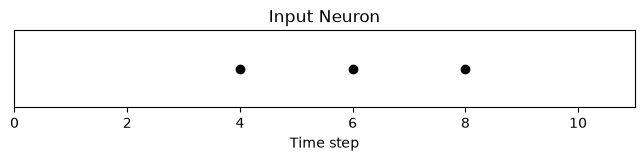

In [114]:
spike_data = spikegen.delta(data, threshold=4)

fig = plt.figure(facecolor="w", figsize=(8, 1))
ax = fig.add_subplot(111)

splt.raster(spike_data, ax, c="black")

plt.title("Input Neuron")
plt.xlabel("Time step")
plt.yticks([])
plt.xlim(0, len(data))
plt.show()

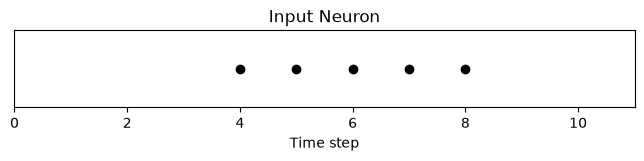

In [115]:
spike_data = spikegen.delta(data, threshold=4, off_spike=True)

fig = plt.figure(facecolor="w", figsize=(8, 1))
ax = fig.add_subplot(111)

splt.raster(spike_data, ax, c="black")

plt.title("Input Neuron")
plt.xlabel("Time step")
plt.yticks([])
plt.xlim(0, len(data))
plt.show()

In [116]:
print(spike_data)

tensor([ 0.,  0.,  0.,  0.,  1., -1.,  1., -1.,  1.,  0.,  0.])


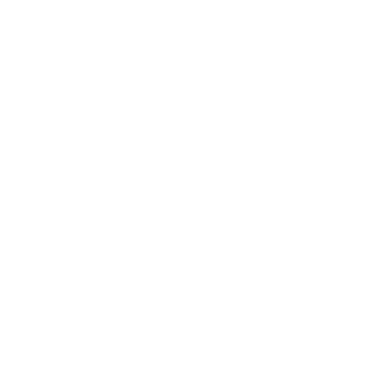

In [117]:
spike_prob = torch.rand((num_steps, 28, 28), dtype=dtype) * 0.5
spike_rand = spikegen.rate_conv(spike_prob)

fig, ax = plt.subplots()
anim = splt.animator(spike_rand, fig, ax)

HTML(anim.to_html5_video())

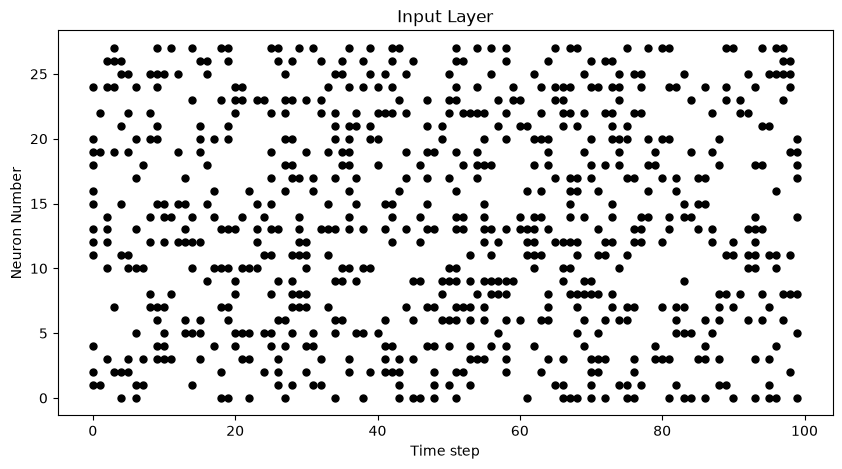

In [118]:
fig = plt.figure(facecolor="w", figsize=(10, 5))
ax = fig.add_subplot(111)
splt.raster(spike_rand[:, 0].view(num_steps, -1), ax, s=25, c="black")

plt.title("Input Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()